# Down sampling

File upload

Saving img_saltandpepper_test.png to img_saltandpepper_test (1).png
Original image shape: (256, 256, 3)


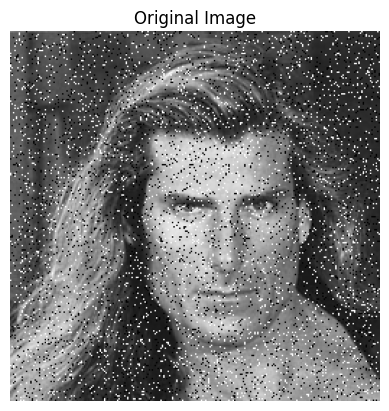

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read image
image_bgr = cv2.imread(filename)

# Convert BGR to RGB
image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print("Original image shape:", image.shape)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

Medium


Original size : (256, 256, 3)
Median size   : (128, 128, 3)


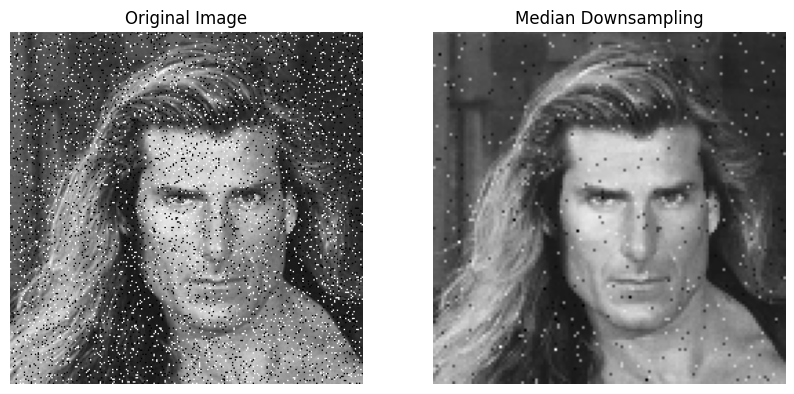

In [ ]:
def downsample_median(image, factor=2):

    height, width, channels = image.shape
    new_height = height // factor
    new_width = width // factor

    result = np.zeros(
        (new_height, new_width, channels),
        dtype=np.uint8)

    for y in range(new_height):
        for x in range(new_width):
            block = image[
                y * factor:(y + 1) * factor,
                x * factor:(x + 1) * factor
            ]
            result[y, x] = np.median(
                block,
                axis=(0, 1)
            )

    return result
median_image = downsample_median(image, 2)
print("Original size :", image.shape)
print("Median size   :", median_image.shape)

# Display result
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(median_image)
plt.title("Median Downsampling")
plt.axis("off")

plt.show()

AVERAGE

Original size : (256, 256, 3)
Average size  : (128, 128, 3)


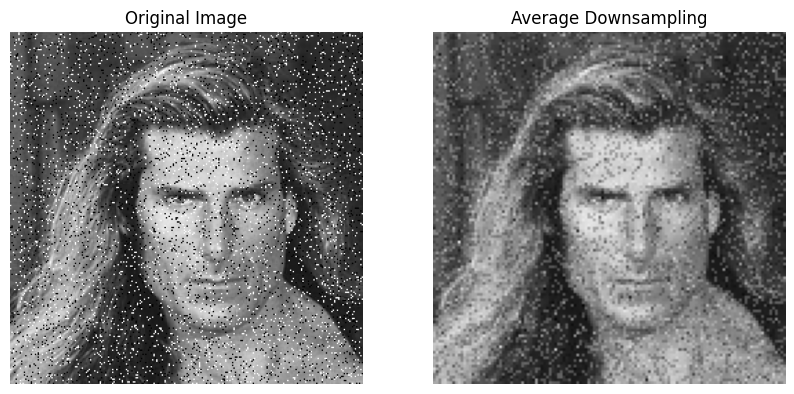

In [ ]:
def downsample_average(image, factor=2):

    height, width, channels = image.shape
    new_height = height // factor
    new_width = width // factor

    result = np.zeros(
        (new_height, new_width, channels),
        dtype=np.uint8)

    for y in range(new_height):
        for x in range(new_width):
            block = image[
                y * factor:(y + 1) * factor,
                x * factor:(x + 1) * factor]
            result[y, x] = np.mean(
                block,
                axis=(0, 1))
    return result
average_image = downsample_average(image, 2)
print("Original size :", image.shape)
print("Average size  :", average_image.shape)

# Display result
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(average_image)
plt.title("Average Downsampling")
plt.axis("off")

plt.show()

MAX

Original size : (256, 256, 3)
Max size      : (128, 128, 3)


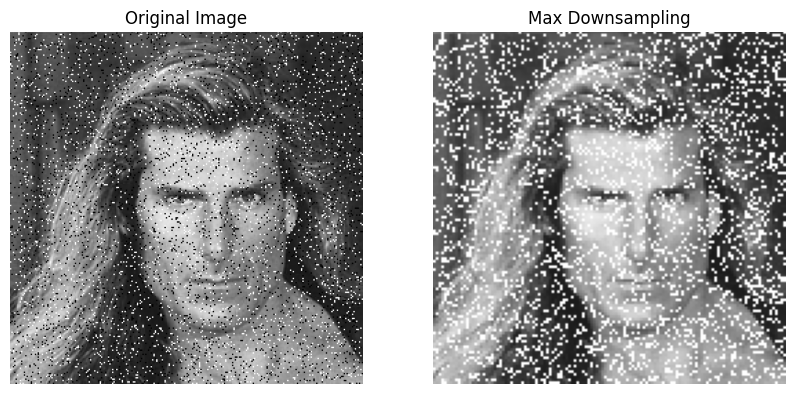

In [ ]:
def downsample_max(image, factor=2):

    height, width, channels = image.shape
    new_height = height // factor
    new_width = width // factor

    result = np.zeros(
        (new_height, new_width, channels),
        dtype=np.uint8)

    for y in range(new_height):
        for x in range(new_width):
            block = image[
                y * factor:(y + 1) * factor,
                x * factor:(x + 1) * factor]
            result[y, x] = np.max(
                block,
                axis=(0, 1))

    return result
max_image = downsample_max(image, 2)
print("Original size :", image.shape)
print("Max size      :", max_image.shape)


# Display result
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(max_image)
plt.title("Max Downsampling")
plt.axis("off")

plt.show()

# Upsampling

Average Donwsample

Saving img_saltandpepper_test.png to img_saltandpepper_test (2).png
Original size : (256, 256, 3)
Average size  : (128, 128, 3)


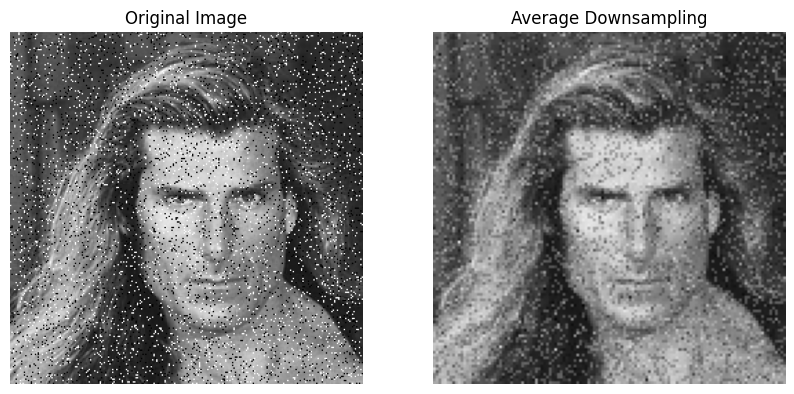

In [ ]:
#reuse the downsample from before
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read image
image_bgr = cv2.imread(filename)

# Convert BGR to RGB
image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

def downsample_average(image, factor=2):

    height, width, channels = image.shape
    new_height = height // factor
    new_width = width // factor

    result = np.zeros(
        (new_height, new_width, channels),
        dtype=np.uint8)

    for y in range(new_height):
        for x in range(new_width):
            block = image[
                y * factor:(y + 1) * factor,
                x * factor:(x + 1) * factor]
            result[y, x] = np.mean(
                block,
                axis=(0, 1))
    return result
average_image = downsample_average(image, 2)
print("Original size :", image.shape)
print("Average size  :", average_image.shape)

# Display result
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(average_image)
plt.title("Average Downsampling")
plt.axis("off")

plt.show()

Input for upsample

Low-resolution image shape: (128, 128, 3)


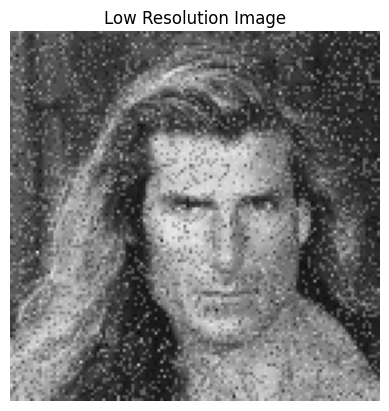

In [ ]:
#use the same low-resolution image
low_resolution = average_image

print("Low-resolution image shape:", low_resolution.shape)

plt.imshow(low_resolution)
plt.title("Low Resolution Image")
plt.axis("off")
plt.show()

Nearest Neighbor Upsampling

Low Resolution : (128, 128, 3)
Nearest Neighbor: (256, 256, 3)


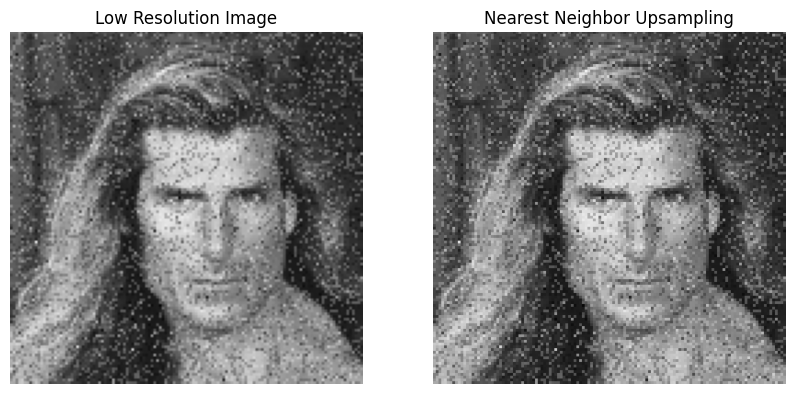

In [ ]:
def upsample_nearest(image, scale=2):

    height, width, channels = image.shape
    new_height = height * scale
    new_width = width * scale

    result = np.zeros(
        (new_height, new_width, channels),
        dtype=np.uint8
    )

    for y_new in range(new_height):
        for x_new in range(new_width):
            y_old = int(y_new / scale)
            x_old = int(x_new / scale)
            result[y_new, x_new] = image[y_old, x_old]
    return result

nearest_image = upsample_nearest(
    low_resolution,
    2
)

print("Low Resolution :", low_resolution.shape)
print("Nearest Neighbor:", nearest_image.shape)

#Display comparison
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(low_resolution)
plt.title("Low Resolution Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(nearest_image)
plt.title("Nearest Neighbor Upsampling")
plt.axis("off")
plt.show()

Billinear Upsampling

Low Resolution: (128, 128, 3)
Bilinear      : (256, 256, 3)


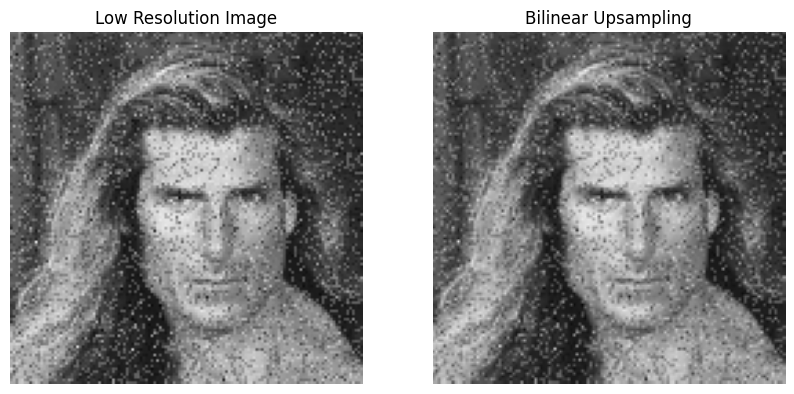

In [ ]:
def upsample_bilinear(image, scale=2):
    height, width, channels = image.shape
    new_height = height * scale
    new_width = width * scale

    result = np.zeros(
        (new_height, new_width, channels),
        dtype=np.uint8
    )

    for y_new in range(new_height):
        for x_new in range(new_width):
            y_old = y_new / scale
            x_old = x_new / scale
            y1 = int(np.floor(y_old))
            x1 = int(np.floor(x_old))
            y2 = min(y1 + 1, height - 1)
            x2 = min(x1 + 1, width - 1)
            dy = y_old - y1
            dx = x_old - x1

            Q11 = image[y1, x1].astype(float)
            Q21 = image[y1, x2].astype(float)
            Q12 = image[y2, x1].astype(float)
            Q22 = image[y2, x2].astype(float)

            value = (
                Q11 * (1 - dx) * (1 - dy)
                + Q21 * dx * (1 - dy)
                + Q12 * (1 - dx) * dy
                + Q22 * dx * dy
            )
            result[y_new, x_new] = np.clip(
                value,
                0,
                255
            )
    return result
bilinear_image = upsample_bilinear(
    low_resolution,
    2
)
print("Low Resolution:", low_resolution.shape)
print("Bilinear      :", bilinear_image.shape)


# Display comparison
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(low_resolution)
plt.title("Low Resolution Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(bilinear_image)
plt.title("Bilinear Upsampling")
plt.axis("off")
plt.show()

Bicubic Upsampling

Low Resolution: (128, 128, 3)
Bicubic       : (256, 256, 3)


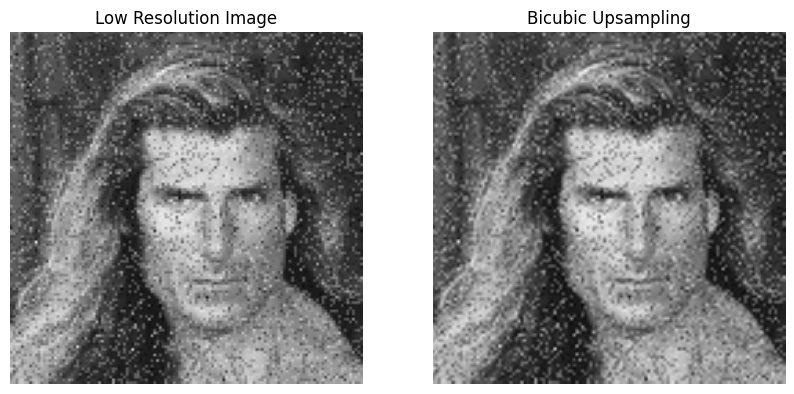

In [ ]:
def cubic_weight(x):

    a = -0.5
    x = abs(x)

    if x <= 1:
        return (
            (a + 2) * x**3
            - (a + 3) * x**2
            + 1
        )
    elif x < 2:
        return (
            a * x**3
            - 5 * a * x**2
            + 8 * a * x
            - 4 * a
        )
    else:
        return 0

def upsample_bicubic(image, scale=2):

    height, width, channels = image.shape

    new_height = height * scale
    new_width = width * scale

    result = np.zeros(
        (new_height, new_width, channels),
        dtype=np.uint8
    )

    for y_new in range(new_height):
        for x_new in range(new_width):

            y_old = y_new / scale
            x_old = x_new / scale

            y_base = int(np.floor(y_old))
            x_base = int(np.floor(x_old))

            pixel_value = np.zeros(
                channels,
                dtype=float
            )
            total_weight = 0.0

            # Use 4 × 4 neighborhood
            for m in range(-1, 3):
                for n in range(-1, 3):

                    y_neighbor = y_base + m
                    x_neighbor = x_base + n

                    # Prevent index outside image
                    y_clamped = min(
                        max(y_neighbor, 0),
                        height - 1
                    )

                    x_clamped = min(
                        max(x_neighbor, 0),
                        width - 1
                    )

                    # Calculate weights
                    weight_y = cubic_weight(
                        y_old - y_neighbor
                    )
                    weight_x = cubic_weight(
                        x_old - x_neighbor
                    )
                    weight = weight_x * weight_y
                    pixel_value += (
                        image[
                            y_clamped,
                            x_clamped
                        ].astype(float)
                        * weight
                    )
                    total_weight += weight
            if total_weight != 0:
                pixel_value /= total_weight

            result[y_new, x_new] = np.clip(
                pixel_value,
                0,
                255
            )
    return result

bicubic_image = upsample_bicubic(
    low_resolution,
    2
)

print("Low Resolution:", low_resolution.shape)
print("Bicubic       :", bicubic_image.shape)

# Display comparison
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(low_resolution)
plt.title("Low Resolution Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(bicubic_image)
plt.title("Bicubic Upsampling")
plt.axis("off")
plt.show()